In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import cv2
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [2]:
train_dataset_path = '/kaggle/input/intel-image-classification/seg_train/seg_train/'
validation_dataset_path = '/kaggle/input/intel-image-classification/seg_test/seg_test/'

In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


In [4]:
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(rescale=1.0/255,
                                  zoom_range=0.2,
                                  width_shift_range=0.2,
                                  height_shift_range=0.2,
                                  fill_mode='nearest')
train_generator = train_datagen.flow_from_directory(train_dataset_path,
                                                   target_size=(IMG_WIDTH, IMG_HEIGHT),
                                                   batch_size=BATCH_SIZE,
                                                   class_mode='categorical',
                                                   shuffle=True)

Found 14034 images belonging to 6 classes.


In [5]:
validation_datagen = ImageDataGenerator(rescale=1.0/255)
validation_generator = validation_datagen.flow_from_directory(validation_dataset_path,
                                                             target_size=(IMG_WIDTH, IMG_HEIGHT),
                                                             batch_size=BATCH_SIZE,
                                                             class_mode='categorical',
                                                             shuffle=True)

Found 3000 images belonging to 6 classes.


In [6]:
labels = {value: key for key, value in train_generator.class_indices.items()}

print("Label Mappings for classes present in the training and validation datasets\n")
for key, value in labels.items():
    print(f"{key} : {value}")

Label Mappings for classes present in the training and validation datasets

0 : buildings
1 : forest
2 : glacier
3 : mountain
4 : sea
5 : street


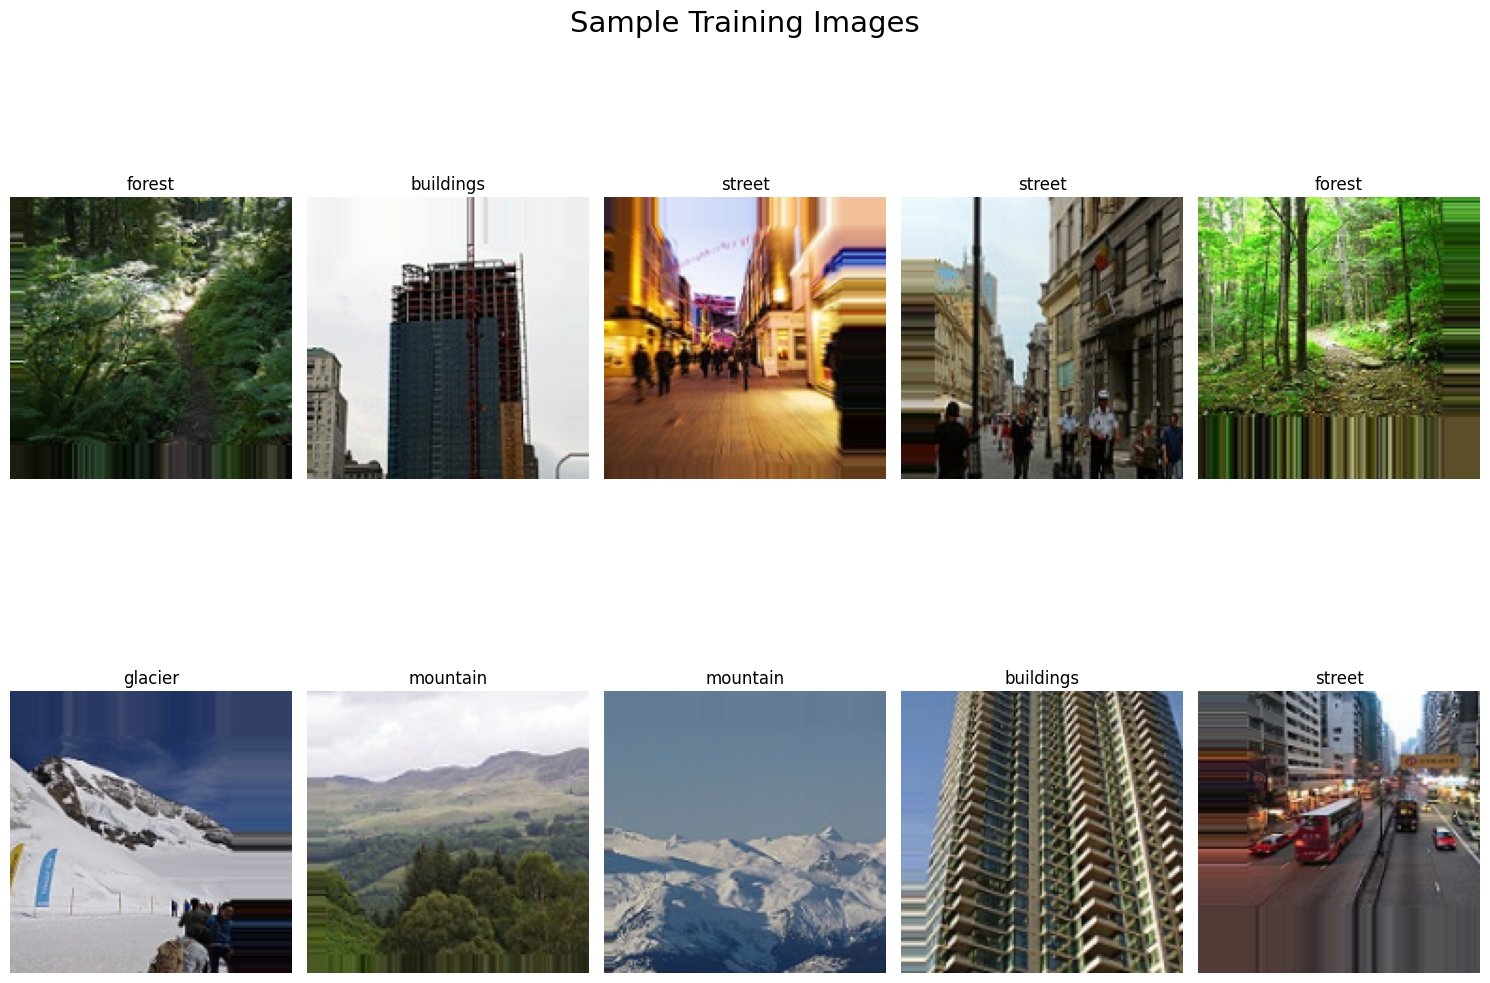

In [7]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(15, 12))
idx = 0

for i in range(2):
    for j in range(5):
        label = labels[np.argmax(train_generator[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_generator[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# Define the Custom KAN Layer
class KANLayer(Layer):
    def __init__(self, units=256):
        super(KANLayer, self).__init__()
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="random_normal",
            trainable=True
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):
        return tf.math.sin(tf.linalg.matmul(inputs, self.w) + self.b)

# Dynamically Determine the Number of Classes
num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")

# Define the CNN-KAN Model
def create_model():
    model = Sequential([
        # Convolutional Layers for Feature Extraction
        Conv2D(128, (5, 5), padding='valid', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        
        Conv2D(64, (3, 3), padding='valid', activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        
        Conv2D(32, (3, 3), padding='valid', activation='relu'),
        MaxPooling2D((2, 2)),
        BatchNormalization(),
        
        # Flatten the Output
        Flatten(),
        
        # KAN Layer as a Feature Extractor
        KANLayer(units=256),
        
        # Dropout for Regularization
        Dropout(0.5),
        
        # Output Layer for Classification
        Dense(num_classes, activation='softmax')  # Dynamically set number of units
    ])
    return model

# Initialize and Compile the Model
model = create_model()
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss=CategoricalCrossentropy(), metrics=['accuracy'])

# Summary of the Model
model.summary()

# Train the Model
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    verbose=2
)

# Evaluate the Model
test_loss, test_accuracy = model.evaluate(validation_generator, batch_size=BATCH_SIZE)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Number of classes: 6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 146, 146, 128)  │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 73, 73, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 71, 71, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 35, 35, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 33, 33, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ kan_layer (KANLayer)            │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,201,830 (8.40 MB)

 Trainable params: 2,201,382 (8.40 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100


I0000 00:00:1776506269.965893      85 service.cc:145] XLA service 0x7a3e38012170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776506269.965944      85 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776506269.965948      85 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776506278.014932      85 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


439/439 - 172s - 392ms/step - accuracy: 0.1711 - loss: 2.4403 - val_accuracy: 0.1937 - val_loss: 2.0653
Epoch 2/100
439/439 - 87s - 199ms/step - accuracy: 0.1635 - loss: 2.3766 - val_accuracy: 0.1657 - val_loss: 2.0523
Epoch 3/100
439/439 - 87s - 198ms/step - accuracy: 0.1684 - loss: 2.2777 - val_accuracy: 0.1653 - val_loss: 2.0177
Epoch 4/100
439/439 - 89s - 204ms/step - accuracy: 0.1717 - loss: 2.2226 - val_accuracy: 0.1553 - val_loss: 2.0341
Epoch 5/100
439/439 - 90s - 205ms/step - accuracy: 0.1694 - loss: 2.1566 - val_accuracy: 0.1743 - val_loss: 1.9780
Epoch 6/100
439/439 - 90s - 204ms/step - accuracy: 0.1651 - loss: 2.1061 - val_accuracy: 0.1723 - val_loss: 1.9371
Epoch 7/100
439/439 - 89s - 204ms/step - accuracy: 0.1679 - loss: 2.0525 - val_accuracy: 0.1667 - val_loss: 1.9113
Epoch 8/100
439/439 - 87s - 198ms/step - accuracy: 0.1737 - loss: 2.0129 - val_accuracy: 0.1717 - val_loss: 1.8841
Epoch 9/100
439/439 - 88s - 202ms/step - accuracy: 0.1709 - loss: 1.9726 - val_accuracy: 0.